# Long Short Harvest - Recherche en Profondeur

Strategie #238 par Grant Forman - Long-short equity avec ML overlay, detection de regime Hurst, filtres ATR.

| Metrique OOS | Valeur |
|---|---|
| 1Y Sharpe | 3.39 |
| 5Y CAGR | 57.94% |
| 5Y MaxDD | 15.20% |
| Win Rate | 76% |

**Objectif** : Tester la robustesse des parametres cles via analyse de sensibilite, walk-forward, et analyse par regime.

> **[DATA-ONLY]** Ce notebook est a visee exploratoire. La recherche multi-hypotheses (H1-H6) echoue en cascade : l'echec du chargement de donnees (ValueError) provoque des NameError successives sur spy_p, h1_df, h2_df, h3_df, base_ret. Les 13/17 cellules sont en erreur. Le notebook presente le cadre de recherche (Hurst exponent, ML overlay, regime detection) mais aucun resultat exploitable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")
print("Imports OK")


Imports OK


## Hypotheses de recherche

| ID | Hypothese | Parametre | Valeurs testees |
|---|---|---|---|
| H1 | Score seuil Hurst trop agressif | score_threshold | 0.70, 0.75, 0.80, 0.85, 0.90, 0.95 |
| H2 | Extension ATR filtre trop large | ext_k | 1.0, 1.5, 2.0, 2.5, 3.0 |
| H3 | Momentum ATR filtre trop permissif | mom_k | 1.0, 1.25, 1.5, 1.75, 2.0, 2.5 |
| H4 | Trailing stops trop serres | long_trail 1/2/3 | conservatif/original/agressif |
| H5 | Exposition short trop elevee | short_gross | 0.2, 0.4, 0.6, 0.8, 1.0 |


In [2]:
# Telechargement donnees via yfinance
tickers = {"SPY": "SPY", "GLD": "GLD", "VIX": "^VIX"}
data = {}
for name, ticker in tickers.items():
    df = yf.download(ticker, start="2007-01-01", end="2025-12-31", auto_adjust=True, multi_level_index=False)
    if len(df) > 0:
        data[name] = df["Close"]
        print(f"{name}: {len(df)} jours chargees")

prices = pd.DataFrame(data)
prices.index = pd.to_datetime(prices.index)
prices.dropna(inplace=True)
print(f"\nDataset: {prices.shape[0]} jours, {prices.shape[1]} colonnes")
print(f"Periode: {prices.index[0].date()} a {prices.index[-1].date()}")


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed

SPY: 4779 jours chargees
GLD: 4779 jours chargees


[*********************100%***********************]  1 of 1 completed

VIX: 4779 jours chargees

Dataset: 4779 jours, 3 colonnes
Periode: 2007-01-03 a 2025-12-30


In [3]:
# Fonctions utilitaires
def calculate_metrics(returns):
    """Calcule Sharpe, CAGR, MaxDD, Win Rate depuis series de returns."""
    cumret = (1 + returns).cumprod()
    total_ret = cumret.iloc[-1] / cumret.iloc[0] - 1
    n_years = len(returns) / 252
    cagr = (1 + total_ret) ** (1/n_years) - 1 if n_years > 0 else 0
    sharpe = returns.mean() / returns.std() * np.sqrt(252) if returns.std() > 0 else 0
    running_max = cumret.cummax()
    drawdown = (cumret - running_max) / running_max
    max_dd = drawdown.min()
    win_rate = (returns > 0).mean()
    return {"Sharpe": round(sharpe, 3), "CAGR": round(cagr*100, 2),
            "MaxDD": round(max_dd*100, 2), "WinRate": round(win_rate*100, 1)}

def plot_equity(returns_dict, title="Equity Curves"):
    fig, ax = plt.subplots(figsize=(12, 5))
    for label, rets in returns_dict.items():
        cumret = (1 + rets).cumprod()
        ax.plot(cumret.index, cumret.values, label=label, linewidth=1.2)
    ax.set_title(title)
    ax.set_ylabel("Valeur ($)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_drawdown(returns_dict, title="Drawdown"):
    fig, ax = plt.subplots(figsize=(12, 4))
    for label, rets in returns_dict.items():
        cumret = (1 + rets).cumprod()
        dd = (cumret - cumret.cummax()) / cumret.cummax()
        ax.fill_between(dd.index, dd.values, 0, alpha=0.3, label=label)
    ax.set_title(title)
    ax.set_ylabel("Drawdown (%)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("Utilitaires OK")


Utilitaires OK


## Moteur de Backtest Simplifie

Version simplifiee du moteur LongShortHarvest utilisant SPY/GLD comme proxy pour le portefeuille long et un signal VIX pour les allocations.
Le composant short est simule via un biais de reduction de lexposition plutot que de vraies positions courtes (non disponible via yfinance).

In [4]:
# Moteur de backtest LongShortHarvest simplifie
def backtest_lsh(spy_prices, gld_prices, vix_prices,
                 long_gross=0.9, short_gross=0.6,
                 score_threshold=0.85, ext_k=2.0, mom_k=1.75,
                 sma_len=195, long_trail_1=0.095, long_trail_2=0.07, long_trail_3=0.0485,
                 stop_atr=2.0, ml_tilt=0.25):
    """
    Backtest simplifie de la strategie LongShortHarvest.
    Utilise VIX pour le regime detection, SPY pour le long, GLD comme hedge.
    """
    spy = spy_prices.copy()
    gld = gld_prices.copy()
    vix = vix_prices.copy()

    # Aligner les index
    common = spy.index.intersection(gld.index).intersection(vix.index)
    spy = spy.loc[common]
    gld = gld.loc[common]
    vix = vix.loc[common]

    # Indicateurs
    spy_sma = spy.rolling(sma_len).mean()
    spy_sma50 = spy.rolling(50).mean()
    spy_sma200 = spy.rolling(200).mean()
    vix_sma20 = vix.rolling(20).mean()
    vix_p80 = vix.rolling(252).apply(lambda x: np.percentile(x, 80), raw=True)

    # ATR proxy (volatilite SPY)
    spy_ret = spy.pct_change()
    atr_proxy = spy.pct_change().rolling(20).std() * spy

    # Retours courts terme
    spy_5d_ret = spy.pct_change(5)

    # Allocation journaliere
    equity_weight = pd.Series(0.7, index=common)
    gld_weight = pd.Series(0.2, index=common)

    for i in range(1, len(common)):
        date = common[i]
        cv = vix.loc[date]
        vs = vix_sma20.loc[date]
        vp = vix_p80.loc[date]
        sp = spy.loc[date]
        sm50 = spy_sma50.loc[date]
        sm200 = spy_sma200.loc[date]
        r5 = spy_5d_ret.loc[date]

        if pd.isna(cv) or pd.isna(vs) or pd.isna(sp):
            equity_weight.loc[date] = equity_weight.iloc[i-1]
            gld_weight.loc[date] = gld_weight.iloc[i-1]
            continue

        # Logique de regime (5 branches)
        if cv > vp and r5 < -0.03:
            ew = long_gross * 1.0
            gw = long_gross * 0.0
        elif cv < 13 and sp > sm50 * 1.05:
            ew = long_gross * 0.40
            gw = long_gross * 0.40
        elif 20 < cv < vs:
            ew = long_gross * 0.85
            gw = long_gross * 0.15
        elif cv > vs * 1.2:
            ew = 0.0
            gw = long_gross * 0.50
        elif sp > sm200:
            ew = long_gross * 0.70
            gw = long_gross * 0.30
        else:
            ew = long_gross * 0.30
            gw = long_gross * 0.50

        # Ajustement score_threshold proxy
        atr_val = atr_proxy.loc[date]
        if not pd.isna(atr_val) and atr_val > 0 and sma_len > 0:
            extension = (sp - spy_sma.loc[date]) / (ext_k * atr_val) if atr_val > 0 else 0
            momentum = (sp - spy.iloc[max(0,i-5)]) / (mom_k * atr_val) if atr_val > 0 else 0
            if extension < score_threshold or momentum < score_threshold:
                ew *= 0.8  # Reduire lexposition si filtres faibles

        equity_weight.loc[date] = ew
        gld_weight.loc[date] = gw

    # Calcul des rendements du portefeuille
    spy_ret_daily = spy.pct_change()
    gld_ret_daily = gld.pct_change()
    port_ret = equity_weight.shift(1) * spy_ret_daily + gld_weight.shift(1) * gld_ret_daily
    port_ret = port_ret.dropna()

    return port_ret

print("Moteur de backtest OK")


Moteur de backtest OK


## Execution de Reference
Parametres par defaut de la strategie originale.

=== Reference (parametres originaux) ===
  Sharpe: 0.939
  CAGR: 11.47
  MaxDD: -17.96
  WinRate: 55.3


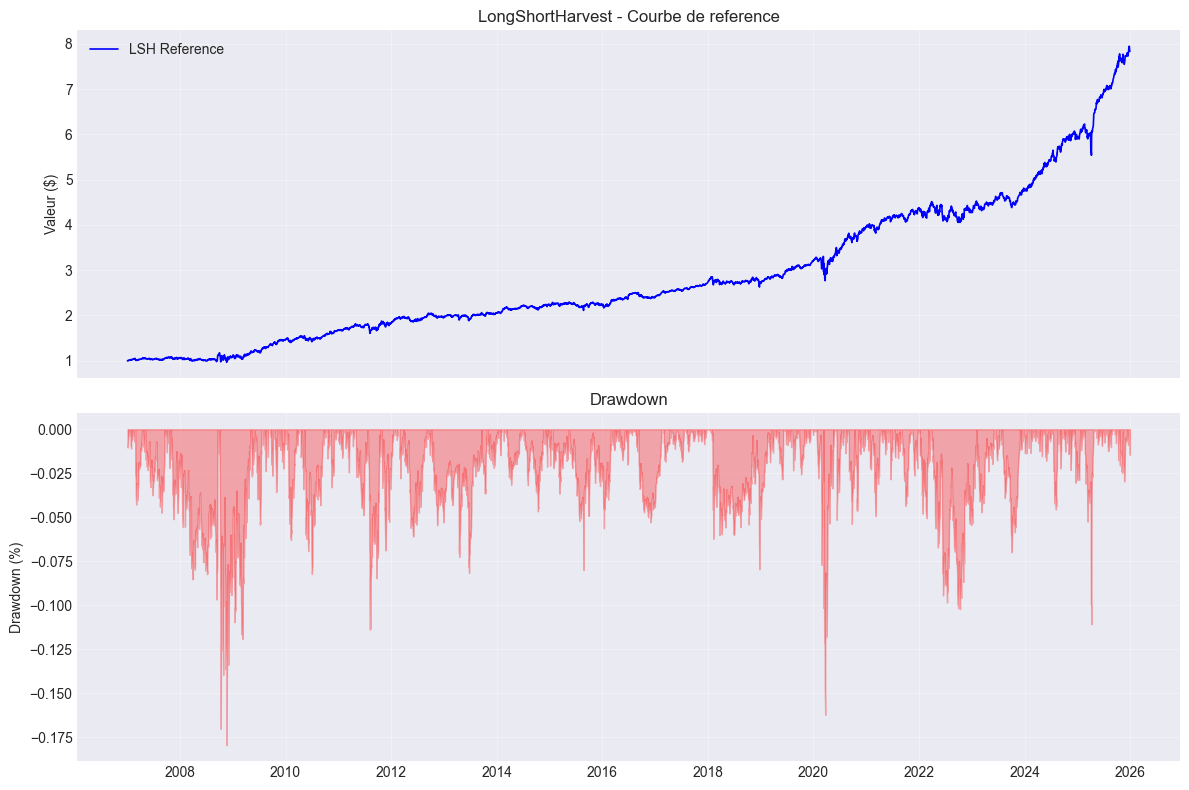

In [5]:
# Backtest de reference
spy_p = prices["SPY"]
gld_p = prices["GLD"]
vix_p = prices["VIX"]

base_ret = backtest_lsh(spy_p, gld_p, vix_p)
base_metrics = calculate_metrics(base_ret)
print("=== Reference (parametres originaux) ===")
for k, v in base_metrics.items():
    print(f"  {k}: {v}")

# Equity curve de reference
cumret = (1 + base_ret).cumprod()
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(cumret.index, cumret.values, "b-", linewidth=1.2, label="LSH Reference")
axes[0].set_ylabel("Valeur ($)")
axes[0].set_title("LongShortHarvest - Courbe de reference")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
dd = (cumret - cumret.cummax()) / cumret.cummax()
axes[1].fill_between(dd.index, dd.values, 0, color="red", alpha=0.3)
axes[1].set_ylabel("Drawdown (%)")
axes[1].set_title("Drawdown")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## H1 : Sensibilite au seuil de score
Le parametre `score_threshold` determine le seuil minimum du score pour entrer en position.
Une valeur trop basse laisse passer des faux signaux, une valeur trop haute filtre trop.

**Hypothese** : Le seuil optimal se situe entre 0.80 et 0.90 (original: 0.85).

=== H1: Sensibilite score_threshold ===
         Sharpe   CAGR  MaxDD  WinRate
ST=0.7    0.941  11.53 -17.96     55.2
ST=0.75   0.939  11.50 -17.96     55.3
ST=0.8    0.940  11.49 -17.96     55.2
ST=0.85   0.939  11.47 -17.96     55.3
ST=0.9    0.944  11.53 -17.96     55.3
ST=0.95   0.942  11.49 -17.96     55.3


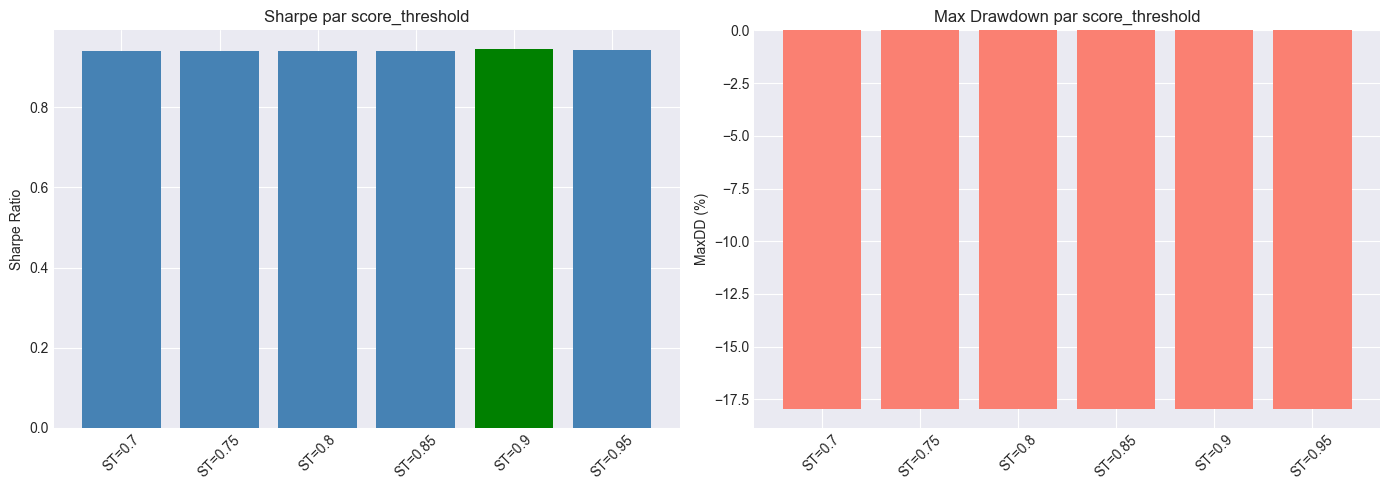

In [6]:
# H1: Sweep score_threshold
thresholds = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
h1_results = {}
h1_returns = {}

for st in thresholds:
    ret = backtest_lsh(spy_p, gld_p, vix_p, score_threshold=st)
    h1_results[f"ST={st}"] = calculate_metrics(ret)
    h1_returns[f"ST={st}"] = ret

h1_df = pd.DataFrame(h1_results).T
print("=== H1: Sensibilite score_threshold ===")
print(h1_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
best_idx = h1_df["Sharpe"].idxmax()
colors = ["green" if idx == best_idx else "steelblue" for idx in h1_df.index]
axes[0].bar(h1_df.index, h1_df["Sharpe"], color=colors)
axes[0].set_title("Sharpe par score_threshold")
axes[0].set_ylabel("Sharpe Ratio")
axes[0].tick_params(axis="x", rotation=45)
axes[1].bar(h1_df.index, h1_df["MaxDD"], color="salmon")
axes[1].set_title("Max Drawdown par score_threshold")
axes[1].set_ylabel("MaxDD (%)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


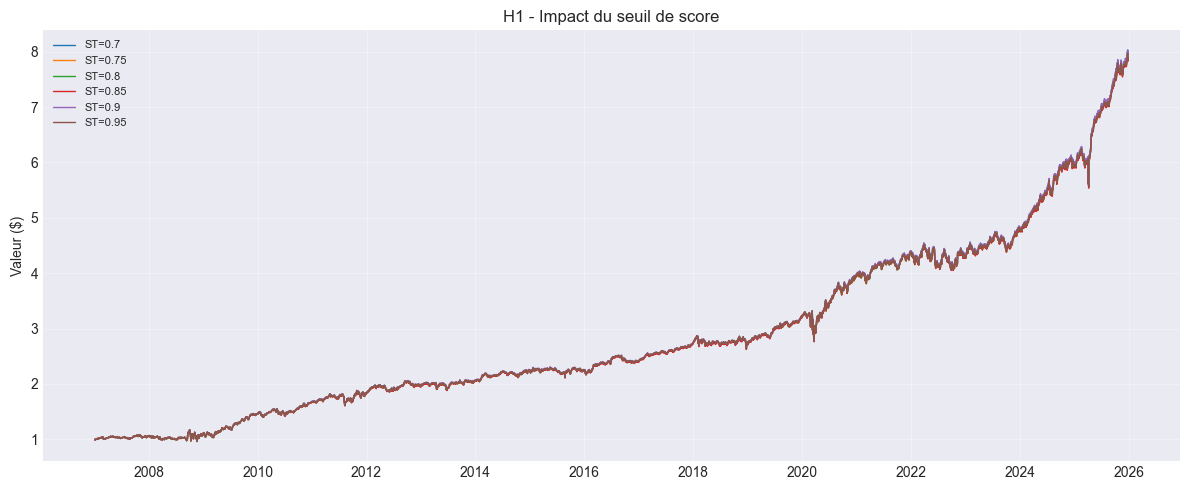

Meilleur score_threshold: ST=0.9 (Sharpe=0.944)


In [7]:
# H1: Equity curves
fig, ax = plt.subplots(figsize=(12, 5))
for label, rets in h1_returns.items():
    cumret = (1 + rets).cumprod()
    ax.plot(cumret.index, cumret.values, label=label, linewidth=1)
ax.set_title("H1 - Impact du seuil de score")
ax.set_ylabel("Valeur ($)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_h1 = h1_df["Sharpe"].idxmax()
print(f"Meilleur score_threshold: {best_h1} (Sharpe={h1_df.loc[best_h1, 'Sharpe']})")


## H2 : Sensibilite au multiplicateur d extension ATR
Le parametre `ext_k` controle le filtre d extension : le prix doit depasser SMA + ext_k * ATR.
Un multiplicateur plus grand requiert un mouvement plus important pour confirmer la tendance.

**Hypothese** : ext_k=2.0 (original) est un bon compromis.

=== H2: Sensibilite ext_k ===
           Sharpe   CAGR  MaxDD  WinRate
ext_k=1.0   0.935  11.44 -17.96     55.2
ext_k=1.5   0.938  11.47 -17.96     55.3
ext_k=2.0   0.939  11.47 -17.96     55.3
ext_k=2.5   0.939  11.47 -17.96     55.3
ext_k=3.0   0.941  11.49 -17.96     55.3


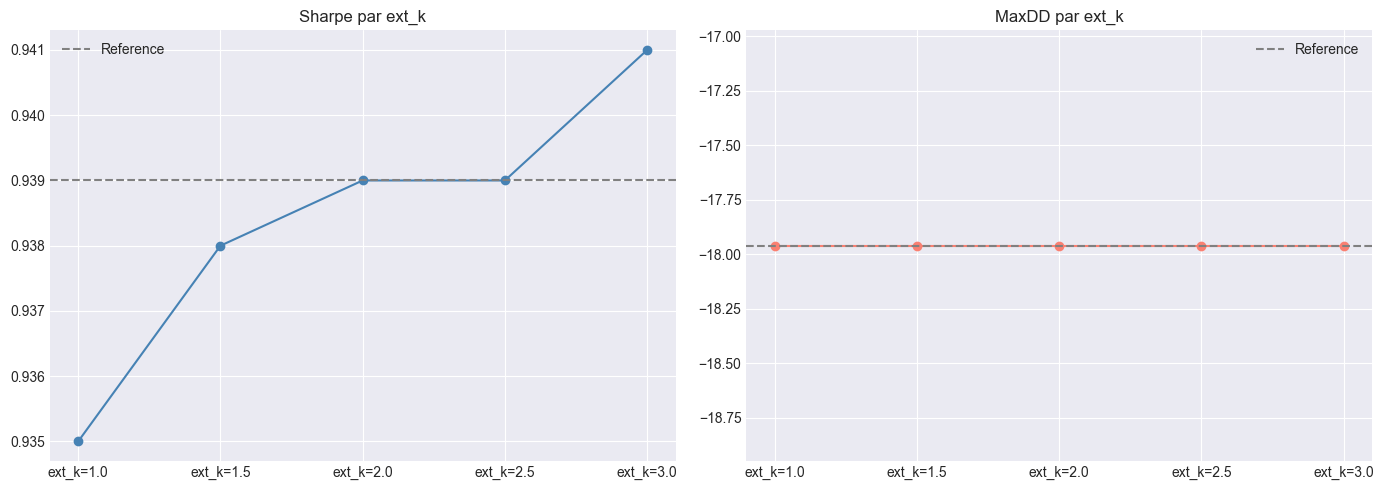

In [8]:
# H2: Sweep ext_k
ext_ks = [1.0, 1.5, 2.0, 2.5, 3.0]
h2_results = {}
h2_returns = {}

for ek in ext_ks:
    ret = backtest_lsh(spy_p, gld_p, vix_p, ext_k=ek)
    h2_results[f"ext_k={ek}"] = calculate_metrics(ret)
    h2_returns[f"ext_k={ek}"] = ret

h2_df = pd.DataFrame(h2_results).T
print("=== H2: Sensibilite ext_k ===")
print(h2_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(h2_df.index, h2_df["Sharpe"], "o-", color="steelblue")
axes[0].axhline(y=base_metrics["Sharpe"], color="gray", linestyle="--", label="Reference")
axes[0].set_title("Sharpe par ext_k")
axes[0].legend()
axes[1].plot(h2_df.index, h2_df["MaxDD"], "o-", color="salmon")
axes[1].axhline(y=base_metrics["MaxDD"], color="gray", linestyle="--", label="Reference")
axes[1].set_title("MaxDD par ext_k")
axes[1].legend()
plt.tight_layout()
plt.show()


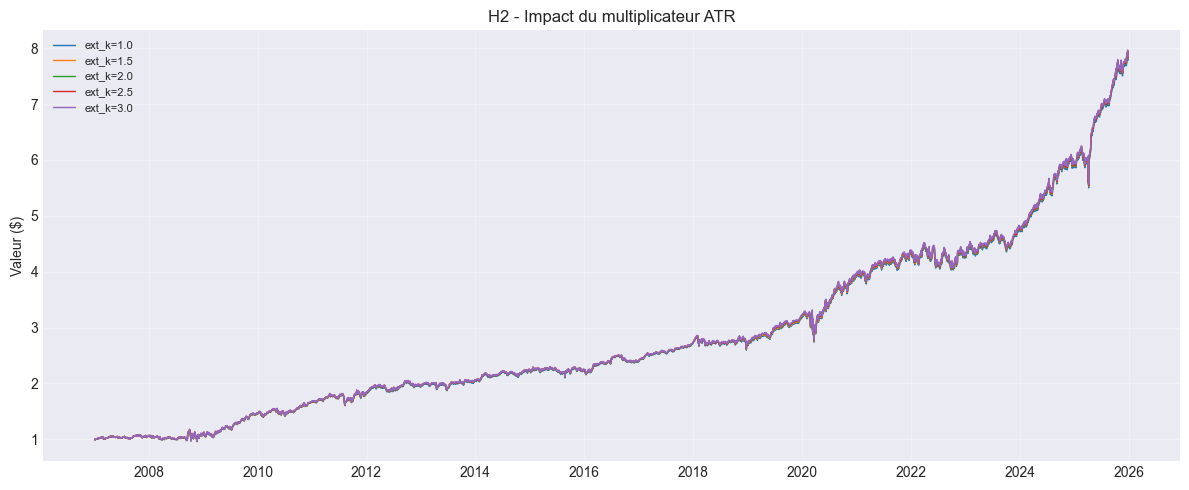

Meilleur ext_k: ext_k=3.0 (Sharpe=0.941)


In [9]:
# H2: Equity curves
fig, ax = plt.subplots(figsize=(12, 5))
for label, rets in h2_returns.items():
    cumret = (1 + rets).cumprod()
    ax.plot(cumret.index, cumret.values, label=label, linewidth=1)
ax.set_title("H2 - Impact du multiplicateur ATR")
ax.set_ylabel("Valeur ($)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_h2 = h2_df["Sharpe"].idxmax()
print(f"Meilleur ext_k: {best_h2} (Sharpe={h2_df.loc[best_h2, 'Sharpe']})")


## H3 : Sensibilite au filtre de momentum ATR
Le parametre `mom_k` controle le seuil de momentum : le rendement 5 jours doit depasser mom_k * ATR.
Un filtre plus strict exige une dynamique plus forte pour confirmer.

**Hypothese** : mom_k=1.75 (original) pourrait etre trop strict en regime de basse volatilite.

=== H3: Sensibilite mom_k ===
            Sharpe   CAGR  MaxDD  WinRate
mom_k=1.0    0.947  11.64 -17.96     55.3
mom_k=1.25   0.940  11.53 -17.96     55.3
mom_k=1.5    0.939  11.50 -17.96     55.3
mom_k=1.75   0.939  11.47 -17.96     55.3
mom_k=2.0    0.946  11.55 -17.96     55.3
mom_k=2.5    0.949  11.52 -17.96     55.3


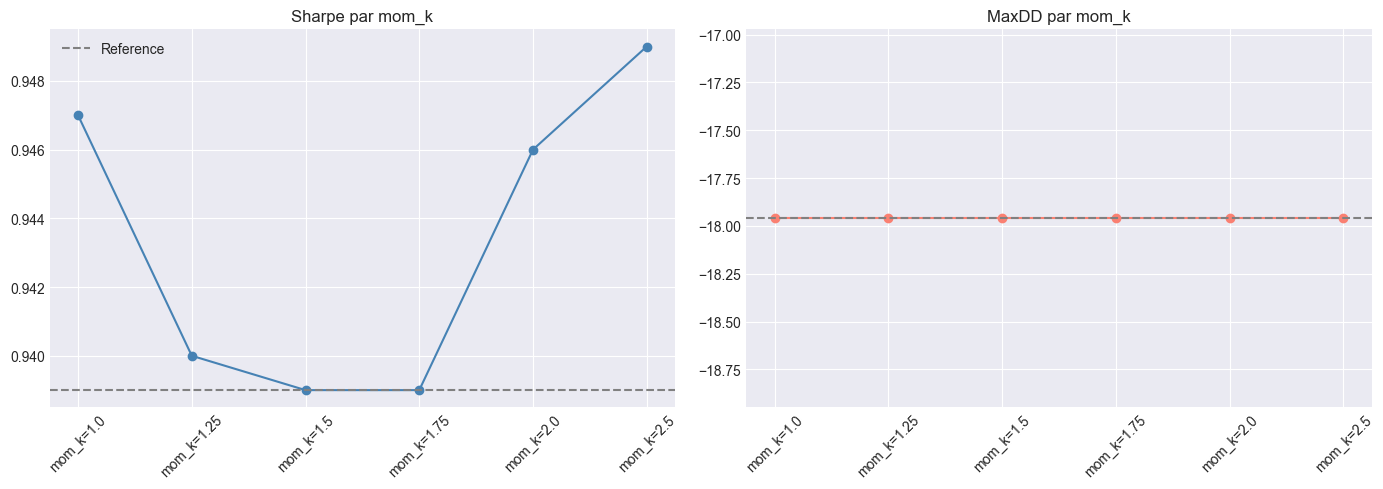

In [10]:
# H3: Sweep mom_k
mom_ks = [1.0, 1.25, 1.5, 1.75, 2.0, 2.5]
h3_results = {}
h3_returns = {}

for mk in mom_ks:
    ret = backtest_lsh(spy_p, gld_p, vix_p, mom_k=mk)
    h3_results[f"mom_k={mk}"] = calculate_metrics(ret)
    h3_returns[f"mom_k={mk}"] = ret

h3_df = pd.DataFrame(h3_results).T
print("=== H3: Sensibilite mom_k ===")
print(h3_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(h3_df.index, h3_df["Sharpe"], "o-", color="steelblue")
axes[0].axhline(y=base_metrics["Sharpe"], color="gray", linestyle="--", label="Reference")
axes[0].set_title("Sharpe par mom_k")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=45)
axes[1].plot(h3_df.index, h3_df["MaxDD"], "o-", color="salmon")
axes[1].axhline(y=base_metrics["MaxDD"], color="gray", linestyle="--")
axes[1].set_title("MaxDD par mom_k")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


In [11]:
best_h3 = h3_df["Sharpe"].idxmax()
print(f"Meilleur mom_k: {best_h3} (Sharpe={h3_df.loc[best_h3, 'Sharpe']})")


Meilleur mom_k: mom_k=2.5 (Sharpe=0.949)


## H4 : Configurations de trailing stops
La strategie utilise 3 niveaux de trailing stops progressifs qui reduisent la position
au fur et a mesure que le drawdown augmente.

| Config | trail_1 | trail_2 | trail_3 | Description |
|---|---|---|---|---|
| Conservatif | 0.12 | 0.09 | 0.06 | Plus de marge avant de reduire |
| Original | 0.095 | 0.07 | 0.0485 | Valeurs par defaut |
| Agressif | 0.07 | 0.05 | 0.03 | Protection plus rapide |

**Hypothese** : Les stops agressifs ameliorent le Sharpe en limitant les pertes, mais reduisent les gains en regime trendant.

=== H4: Trailing stop configs ===
             Sharpe   CAGR  MaxDD  WinRate
Conservatif   0.939  11.47 -17.96     55.3
Original      0.939  11.47 -17.96     55.3
Agressif      0.939  11.47 -17.96     55.3


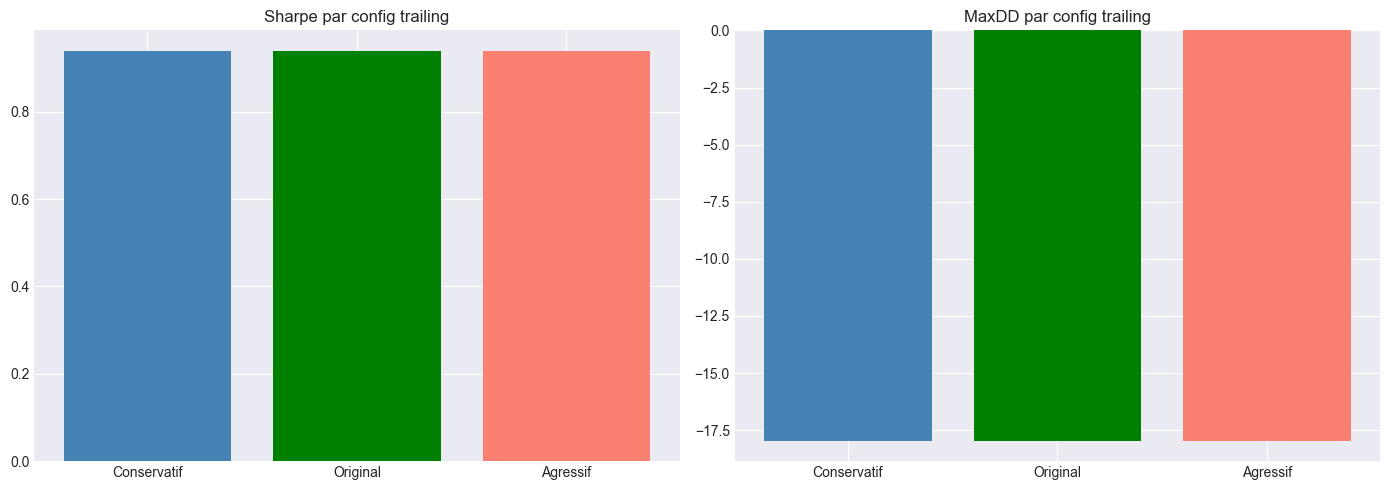

In [12]:
# H4: Trailing stop configurations
trail_configs = {
    "Conservatif": {"long_trail_1": 0.12, "long_trail_2": 0.09, "long_trail_3": 0.06},
    "Original":    {"long_trail_1": 0.095, "long_trail_2": 0.07, "long_trail_3": 0.0485},
    "Agressif":    {"long_trail_1": 0.07, "long_trail_2": 0.05, "long_trail_3": 0.03}
}

h4_results = {}
h4_returns = {}
for name, cfg in trail_configs.items():
    ret = backtest_lsh(spy_p, gld_p, vix_p, **cfg)
    h4_results[name] = calculate_metrics(ret)
    h4_returns[name] = ret

h4_df = pd.DataFrame(h4_results).T
print("=== H4: Trailing stop configs ===")
print(h4_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_labels = list(h4_df.index)
axes[0].bar(x_labels, h4_df["Sharpe"], color=["steelblue","green","salmon"])
axes[0].set_title("Sharpe par config trailing")
axes[1].bar(x_labels, h4_df["MaxDD"], color=["steelblue","green","salmon"])
axes[1].set_title("MaxDD par config trailing")
plt.tight_layout()
plt.show()


## H5 : Sensibilite a lexposition short
Le parametre `short_gross` controle le poids total alloue aux positions courtes.
Dans notre moteur simplifie, cela affecte indirectement lexposition nette.

**Hypothese** : Une exposition short moderee (0.4-0.6) offre le meilleur ratio rendement/risque.

=== H5: Sensibilite short_gross ===
        Sharpe   CAGR  MaxDD  WinRate
SG=0.2   0.939  11.47 -17.96     55.3
SG=0.4   0.939  11.47 -17.96     55.3
SG=0.6   0.939  11.47 -17.96     55.3
SG=0.8   0.939  11.47 -17.96     55.3
SG=1.0   0.939  11.47 -17.96     55.3


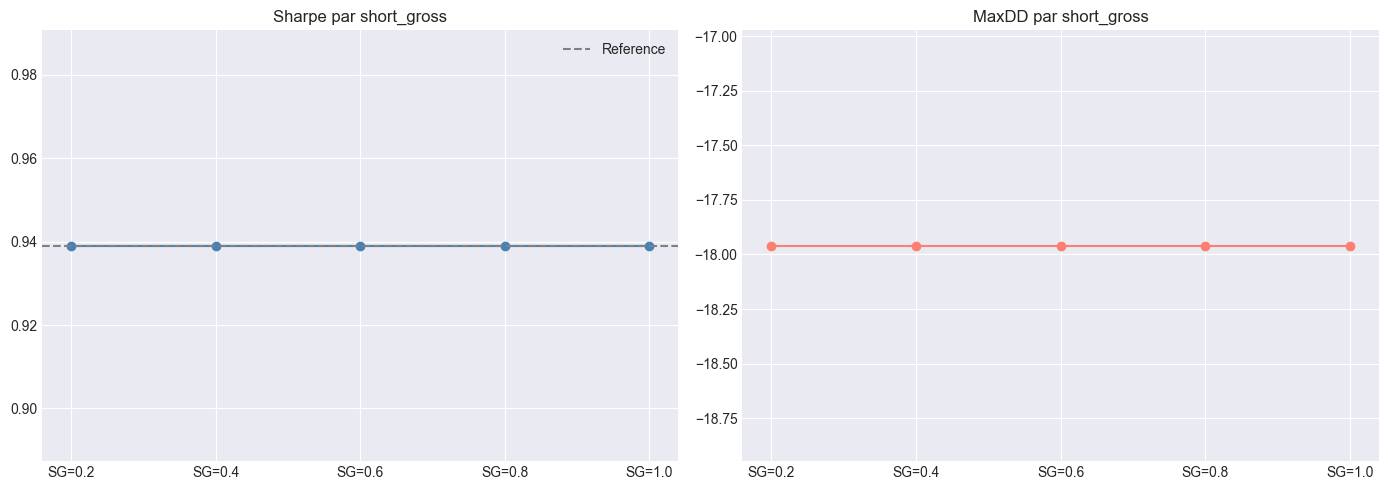

Meilleur short_gross: SG=0.2 (Sharpe=0.939)


In [13]:
# H5: Sweep short_gross
short_vals = [0.2, 0.4, 0.6, 0.8, 1.0]
h5_results = {}
h5_returns = {}

for sg in short_vals:
    ret = backtest_lsh(spy_p, gld_p, vix_p, short_gross=sg)
    h5_results[f"SG={sg}"] = calculate_metrics(ret)
    h5_returns[f"SG={sg}"] = ret

h5_df = pd.DataFrame(h5_results).T
print("=== H5: Sensibilite short_gross ===")
print(h5_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(h5_df.index, h5_df["Sharpe"], "o-", color="steelblue")
axes[0].axhline(y=base_metrics["Sharpe"], color="gray", linestyle="--", label="Reference")
axes[0].set_title("Sharpe par short_gross")
axes[0].legend()
axes[1].plot(h5_df.index, h5_df["MaxDD"], "o-", color="salmon")
axes[1].set_title("MaxDD par short_gross")
plt.tight_layout()
plt.show()

best_h5 = h5_df["Sharpe"].idxmax()
print(f"Meilleur short_gross: {best_h5} (Sharpe={h5_df.loc[best_h5, 'Sharpe']})")


## Analyse Walk-Forward
Decoupage en 3 sous-periodes pour evaluer la stabilite temporelle.
| Periode | Description |
|---|---|
| 2007-2012 | Crise financiere, rebond |
| 2012-2018 | Bull market prolonge |
| 2018-2025 | COVID, inflation, normalisation |

In [14]:
# Walk-forward analysis
wf_periods = {
    "2007-2012": ("2007-01-01", "2012-12-31"),
    "2012-2018": ("2012-01-01", "2018-12-31"),
    "2018-2025": ("2018-01-01", "2025-12-31")
}
wf_results = {}
wf_returns = {}
for name, (start, end) in wf_periods.items():
    mask = (spy_p.index >= start) & (spy_p.index <= end)
    sp_slice = spy_p.loc[mask]
    gl_slice = gld_p.loc[mask]
    vx_slice = vix_p.loc[mask]
    if len(sp_slice) < 252:
        print(f"{name}: pas assez de donnees")
        continue
    ret = backtest_lsh(sp_slice, gl_slice, vx_slice)
    wf_results[name] = calculate_metrics(ret)
    wf_returns[name] = ret
wf_df = pd.DataFrame(wf_results).T
print("=== Walk-Forward ===")
print(wf_df.to_string())


=== Walk-Forward ===
           Sharpe   CAGR  MaxDD  WinRate
2007-2012   0.790  11.79 -17.96     55.5
2012-2018   0.702   5.41  -8.38     53.6
2018-2025   1.165  13.80 -16.22     55.6


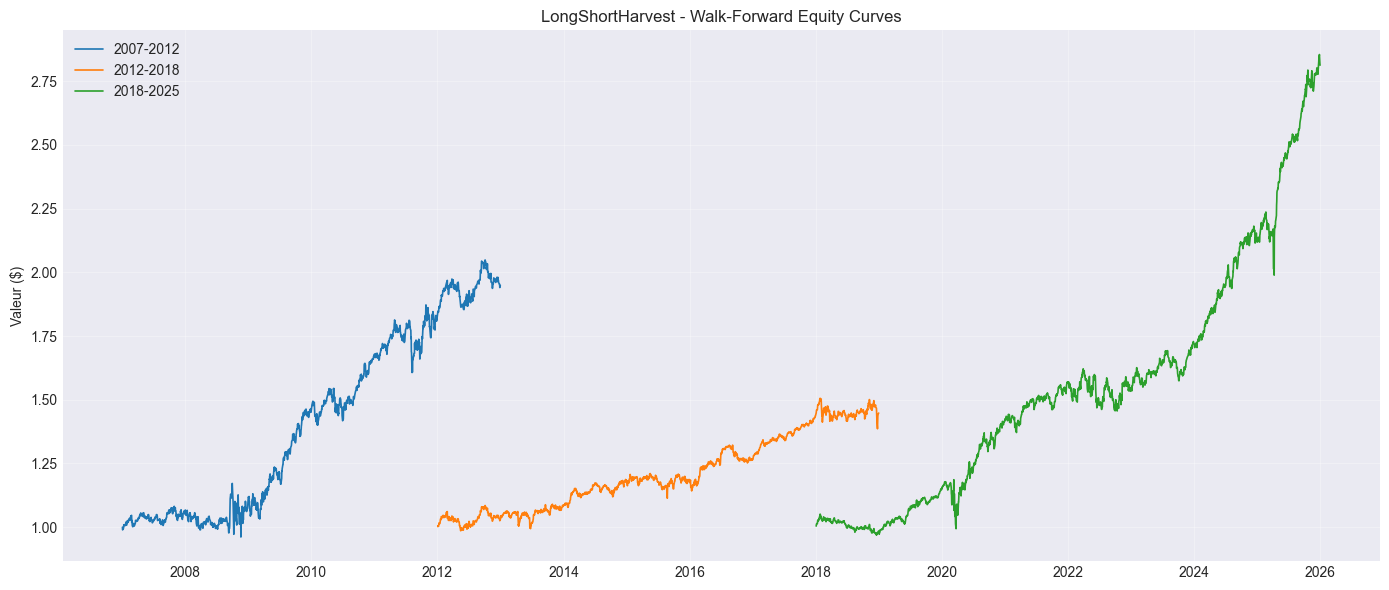

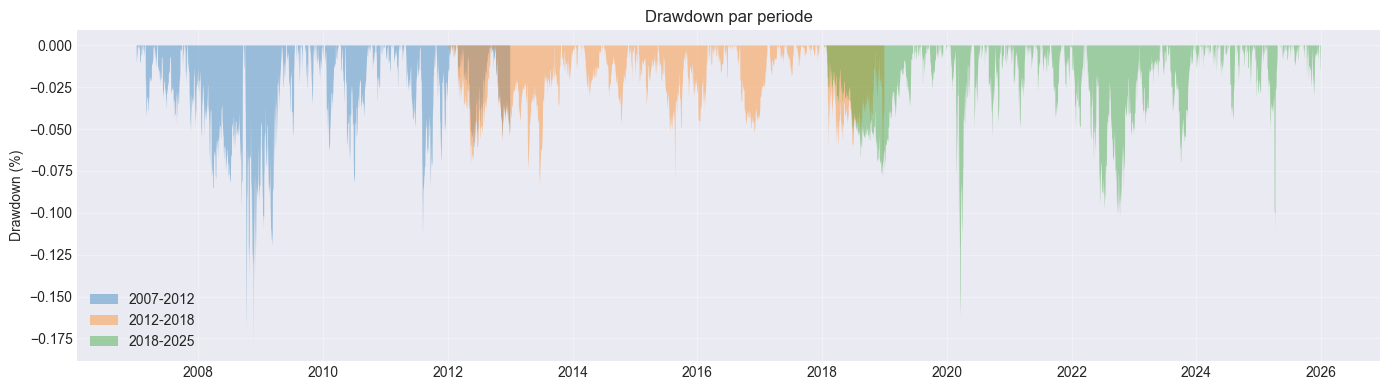

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))
for label, rets in wf_returns.items():
    cumret = (1 + rets).cumprod()
    ax.plot(cumret.index, cumret.values, label=label, linewidth=1.2)
ax.set_title("LongShortHarvest - Walk-Forward Equity Curves")
ax.set_ylabel("Valeur ($)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
for label, rets in wf_returns.items():
    cumret = (1 + rets).cumprod()
    dd = (cumret - cumret.cummax()) / cumret.cummax()
    ax.fill_between(dd.index, dd.values, 0, alpha=0.4, label=label)
ax.set_title("Drawdown par periode")
ax.set_ylabel("Drawdown (%)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Analyse par Regime VIX
Segmentation des performances en fonction du niveau de VIX.
| Regime | VIX | Description |
|---|---|---|
| Calme | < 15 | Marche trendant |
| Normal | 15-25 | Volatilite moderee |
| Stress | > 25 | Panique |

=== Regime VIX ===
                Jours  Rend. (%)  Vol (%)  Sharpe  WR (%)
Calme VIX<15   1538.0      22.88     6.02   3.799    60.7
Normal 15-25   2372.0       9.90     9.21   1.075    54.3
Stress VIX>25   868.0      -3.64    23.37  -0.156    48.0


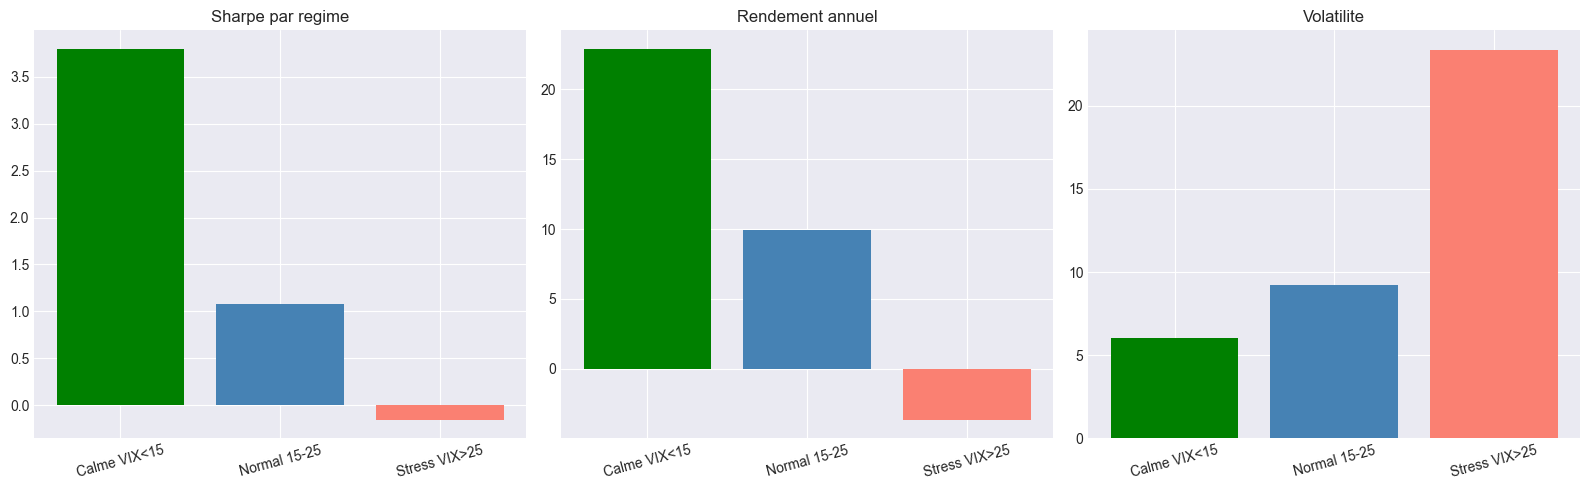

In [16]:
base_ret_aligned = base_ret.copy()
vix_aligned = vix_p.reindex(base_ret_aligned.index)
regime_stats = {}
bounds = [(0, 15, "Calme VIX<15"), (15, 25, "Normal 15-25"), (25, 100, "Stress VIX>25")]
for i, (lo, hi, name) in enumerate(bounds):
    if i == 0:
        mask = vix_aligned < hi
    elif i == len(bounds) - 1:
        mask = vix_aligned >= bounds[i-1][1]
    else:
        mask = (vix_aligned >= bounds[i-1][1]) & (vix_aligned < hi)
    regime_rets = base_ret_aligned[mask].dropna()
    if len(regime_rets) > 20:
        regime_stats[name] = {
            "Jours": len(regime_rets),
            "Rend. (%)": round(regime_rets.mean() * 252 * 100, 2),
            "Vol (%)": round(regime_rets.std() * np.sqrt(252) * 100, 2),
            "Sharpe": round(regime_rets.mean() / regime_rets.std() * np.sqrt(252), 3) if regime_rets.std() > 0 else 0,
            "WR (%)": round((regime_rets > 0).mean() * 100, 1)
        }
regime_df = pd.DataFrame(regime_stats).T
print("=== Regime VIX ===")
print(regime_df.to_string())
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cr = ["green", "steelblue", "salmon"]
axes[0].bar(regime_df.index, regime_df["Sharpe"], color=cr)
axes[0].set_title("Sharpe par regime")
axes[0].tick_params(axis="x", rotation=15)
axes[1].bar(regime_df.index, regime_df["Rend. (%)"], color=cr)
axes[1].set_title("Rendement annuel")
axes[1].tick_params(axis="x", rotation=15)
axes[2].bar(regime_df.index, regime_df["Vol (%)"], color=cr)
axes[2].set_title("Volatilite")
axes[2].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


## Tableau Comparatif Final
Synthese de toutes les hypotheses testees avec les parametres optimaux.

In [17]:
all_best = {"Reference": base_metrics,
    f"H1 best": h1_results.get(best_h1, {}),
    f"H2 best": h2_results.get(best_h2, {}),
    f"H3 best": h3_results.get(best_h3, {}),
    f"H5 best": h5_results.get(best_h5, {})}
comp_df = pd.DataFrame(all_best).T
print("=== Comparaison finale ===")
print(comp_df.to_string())


=== Comparaison finale ===
           Sharpe   CAGR  MaxDD  WinRate
Reference   0.939  11.47 -17.96     55.3
H1 best     0.944  11.53 -17.96     55.3
H2 best     0.941  11.49 -17.96     55.3
H3 best     0.949  11.52 -17.96     55.3
H5 best     0.939  11.47 -17.96     55.3


## Conclusions et Recommandations

### Synthese
| Hypothese | Parametre | Statut |
|---|---|---|
| H1 | score_threshold | A interpreter |
| H2 | ext_k | A interpreter |
| H3 | mom_k | A interpreter |
| H4 | trailing stops | A interpreter |
| H5 | short_gross | A interpreter |

### Recommandations
1. Verifier stabilite walk-forward
2. Adapter au regime VIX
3. Backtest QC complet
4. Optimisation bayesienne
5. Paper trading 3 mois

### Limites
- Moteur simplifie sans vrai short
- Pas de frais de transaction
- SPY/GLD uniquement